In [1]:
import os

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb


In [2]:
from sklearn.metrics import mean_squared_error

color_pal = sns.color_palette()

plt.style.use('fivethirtyeight')


In [3]:
df = pd.read_csv('archive (1)/PJME_hourly.csv')
df = df.set_index("Datetime")
df.index = pd.to_datetime(df.index)


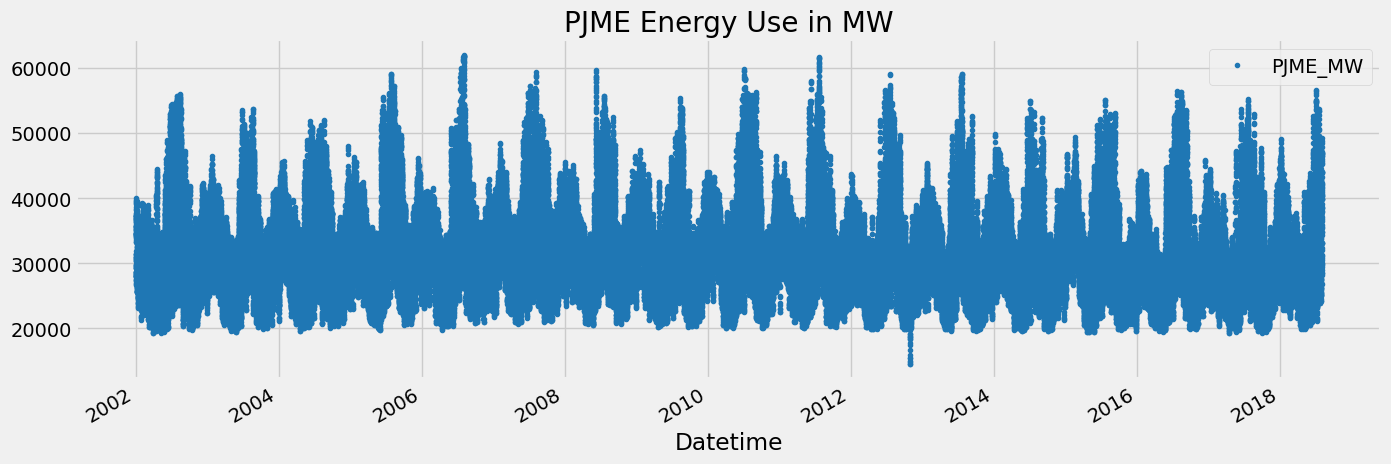

In [4]:
df.plot(style=".", figsize=(15, 5), color=color_pal[0], title="PJME Energy Use in MW")
plt.show()


# Train Test Split

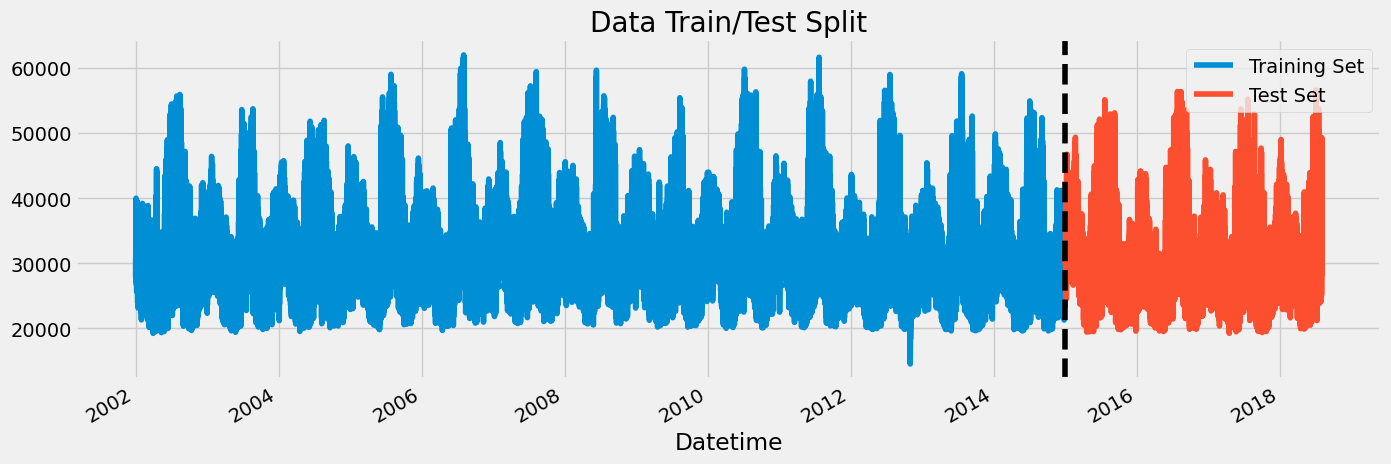

In [5]:
train = df.loc[df.index < '01-01-2015']
test = df.loc[df.index >= '01-01-2015']

fig, ax = plt.subplots(figsize=(15, 5))
train.plot(ax=ax, label="Training Set", title="Data Train/Test Split")
test.plot(ax=ax, label="Test Set")
ax.axvline("01-01-2015", color="black", ls="--")
ax.legend(["Training Set", "Test Set"])
plt.show()


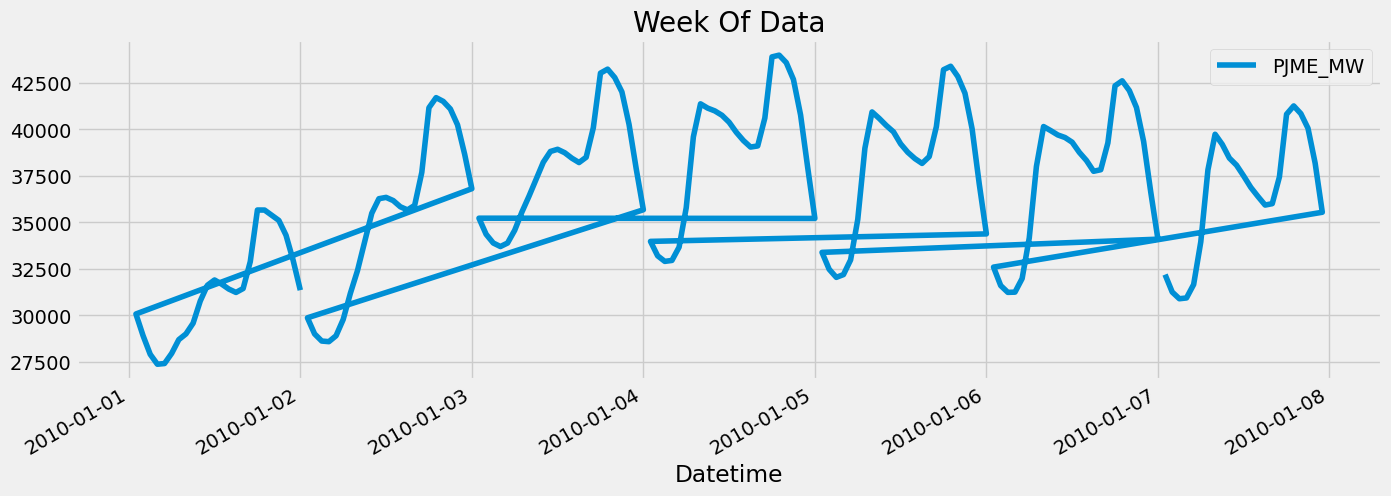

In [6]:
df.loc[(df.index > "01-01-2010") & (df.index < "01-08-2010")].plot(
    figsize=(15, 5), title="Week Of Data"
)
plt.show()


In [7]:
def create_features(df):
    """
    Create time series features based on time series index.
    """
    df = df.copy()
    df["hour"] = df.index.hour
    df["dayofweek"] = df.index.dayofweek
    df["quarter"] = df.index.quarter
    df["month"] = df.index.month
    df["year"] = df.index.year
    df["dayofyear"] = df.index.dayofyear
    df["dayofmonth"] = df.index.day
    df["weekofyear"] = df.index.isocalendar().week
    return df

df = create_features(df)


C:\Users\farma\AppData\Local\Temp\ipykernel_10616\2548931321.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="month", y="PJME_MW", palette="Blues")


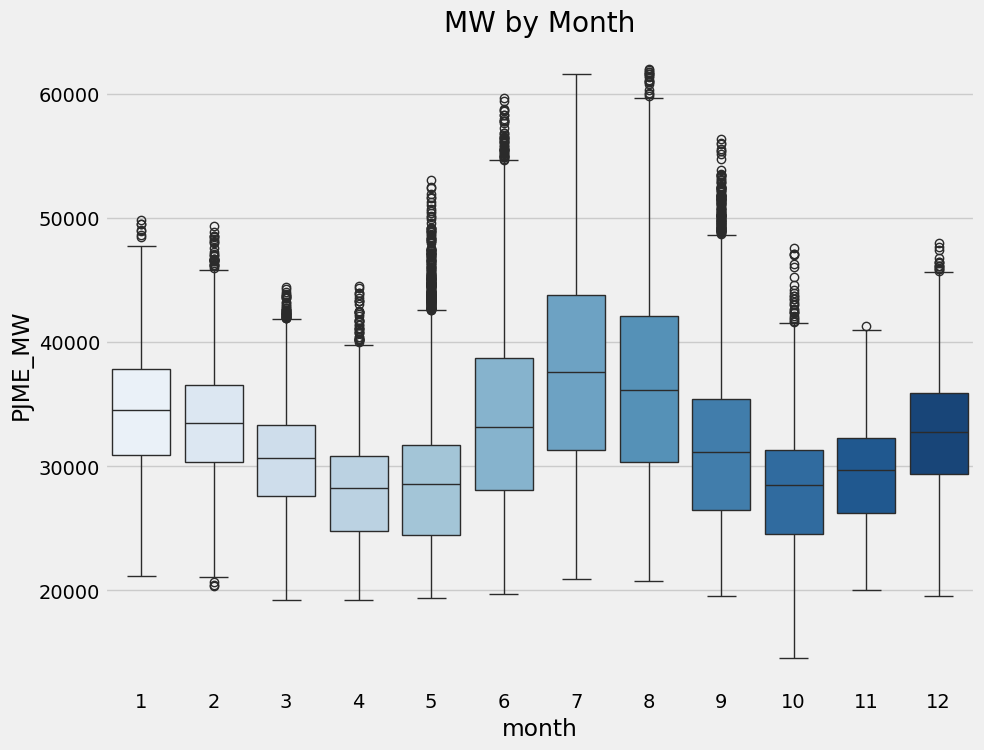

In [8]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.boxplot(data=df, x="month", y="PJME_MW", palette="Blues")
ax.set_title("MW by Month")
plt.show()


In [9]:
train = create_features(train)

test = create_features(test)

FEATURES = ["dayofyear", "hour", "dayofweek", "quarter", "month", "year"]
TARGET = "PJME_MW"



X_train = train[FEATURES]
y_train = train[TARGET]

X_test = test[FEATURES]
y_test = test[TARGET]


In [10]:

reg = xgb.XGBRegressor(
  base_score=0.5,
  booster='gbtree',
  n_estimators=1000,
  early_stopping_rounds=50,
  objective ='reg:linear',
  max_depth=3,
  learning_rate=0.01,
)




reg.fit(
  X_train,y_train,
  eval_set=[(X_train, y_train), (X_test, y_test)],
  verbose=100
)


[0]	validation_0-rmse:32605.13605	validation_1-rmse:31657.15764


C:\Users\farma\AppData\Roaming\Python\Python313\site-packages\xgboost\callback.py:385: UserWarning: [18:31:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\objective\regression_obj.cu:275: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()


[100]	validation_0-rmse:12584.39056	validation_1-rmse:11748.11705
[200]	validation_0-rmse:5836.77238	validation_1-rmse:5367.04380
[300]	validation_0-rmse:3926.15291	validation_1-rmse:4027.50726
[400]	validation_0-rmse:3449.08367	validation_1-rmse:3857.89224
[500]	validation_0-rmse:3287.44954	validation_1-rmse:3810.04866
[600]	validation_0-rmse:3205.27700	validation_1-rmse:3779.54935
[700]	validation_0-rmse:3152.31354	validation_1-rmse:3757.49855
[800]	validation_0-rmse:3111.75657	validation_1-rmse:3741.12979
[900]	validation_0-rmse:3081.00370	validation_1-rmse:3731.11182
[999]	validation_0-rmse:3054.05758	validation_1-rmse:3728.47773


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:linear'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",0.5
,booster,'gbtree'
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_

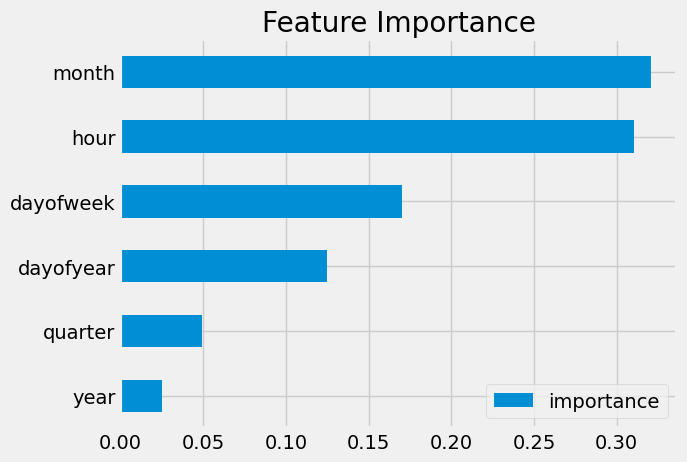

In [11]:
fi = pd.DataFrame(
    data=reg.feature_importances_, index=reg.feature_names_in_, columns=["importance"]
)
fi.sort_values("importance").plot(kind="barh", title="Feature Importance")
plt.show()


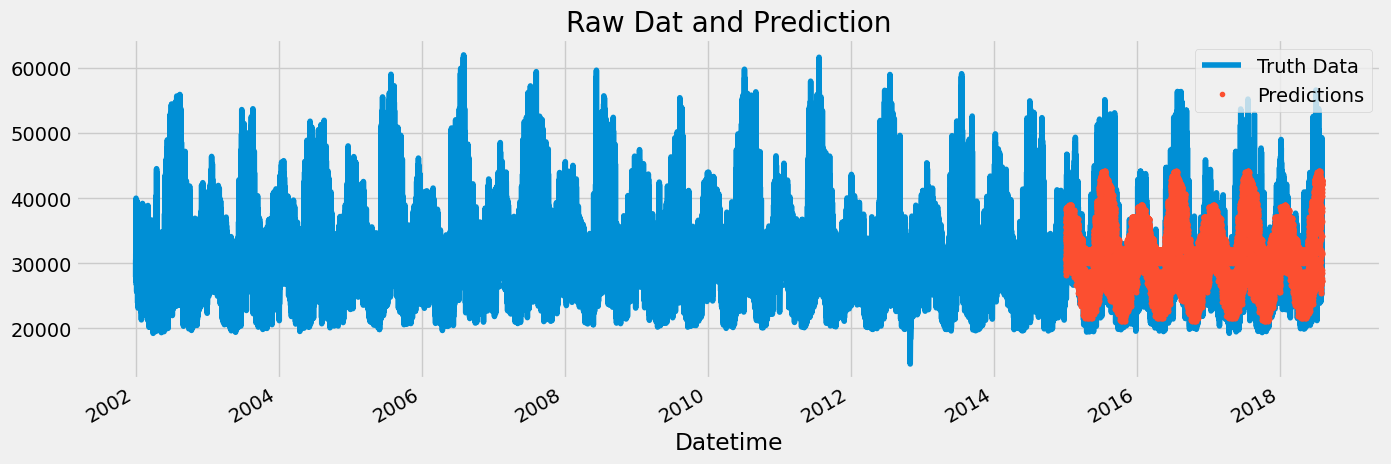

In [12]:
test["prediction"] = reg.predict(X_test)
df = df.merge(test[["prediction"]], how="left", left_index=True, right_index=True)
ax = df[["PJME_MW"]].plot(figsize=(15, 5))
df["prediction"].plot(ax=ax, style=".")
plt.legend(["Truth Data", "Predictions"])
ax.set_title("Raw Dat and Prediction")
plt.show()


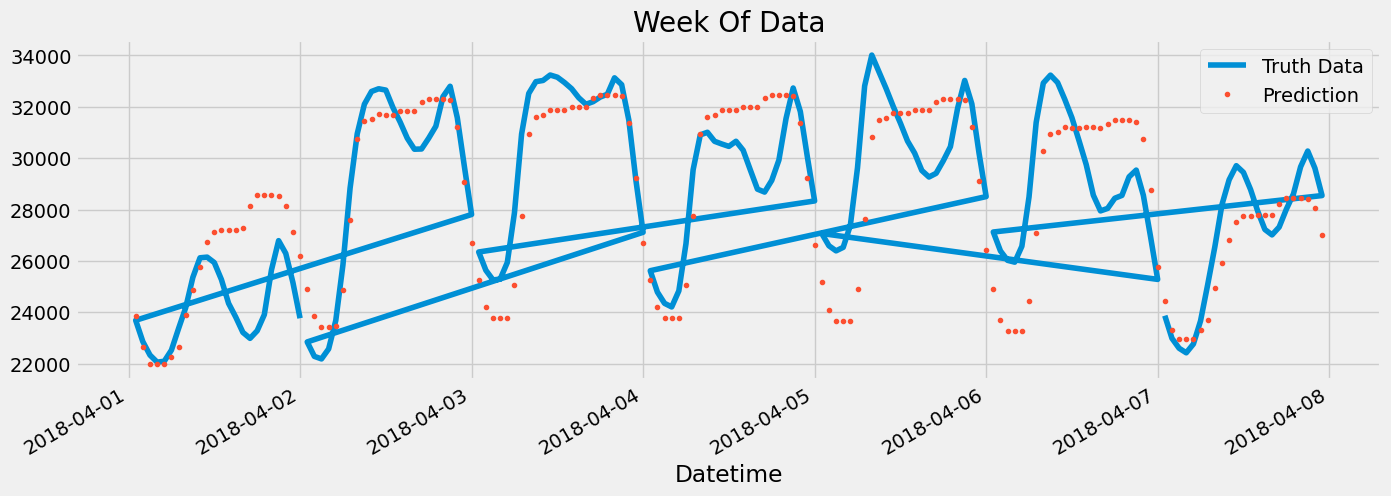

In [13]:
ax = df.loc[(df.index > "04-01-2018") & (df.index < "04-08-2018")]["PJME_MW"].plot(
    figsize=(15, 5), title="Week Of Data"
)
df.loc[(df.index > "04-01-2018") & (df.index < "04-08-2018")]["prediction"].plot(
    style="."
)
plt.legend(["Truth Data", "Prediction"])
plt.show()


In [14]:
score = np.sqrt(mean_squared_error(test["PJME_MW"], test["prediction"]))
print(f"RMSE Score on Test set: {score:0.2f}")


RMSE Score on Test set: 3726.96


In [15]:
test["error"] = np.abs(test[TARGET] - test["prediction"])
test["date"] = test.index.date
test.groupby(["date"])["error"].mean().sort_values(ascending=False).head(10)


date
2016-08-13    12869.534180
2016-08-14    12829.259928
2016-09-10    12163.427979
2015-02-20    11088.546224
2016-09-09    10848.283447
2018-01-06    10539.788981
2016-08-12    10121.320068
2015-02-21    10012.706217
2015-02-16     9875.644938
2018-01-07     9756.988525
Name: error, dtype: float64

<Axes: ylabel='Frequency'>

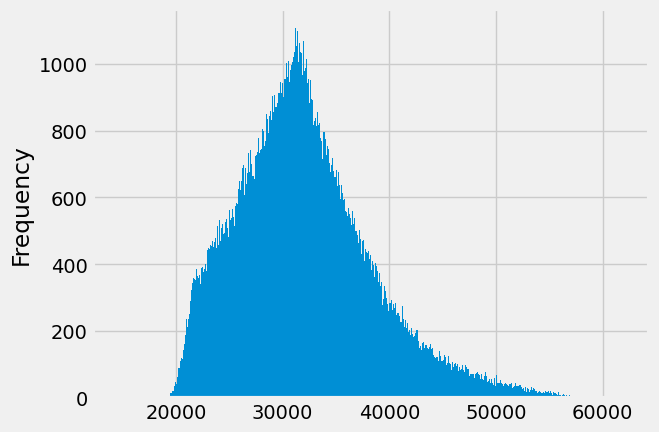

In [ ]:
df["PJME_MW"].plot(kind="hist", bins=500)


<Axes: title={'center': 'Outliers'}, xlabel='Datetime'>

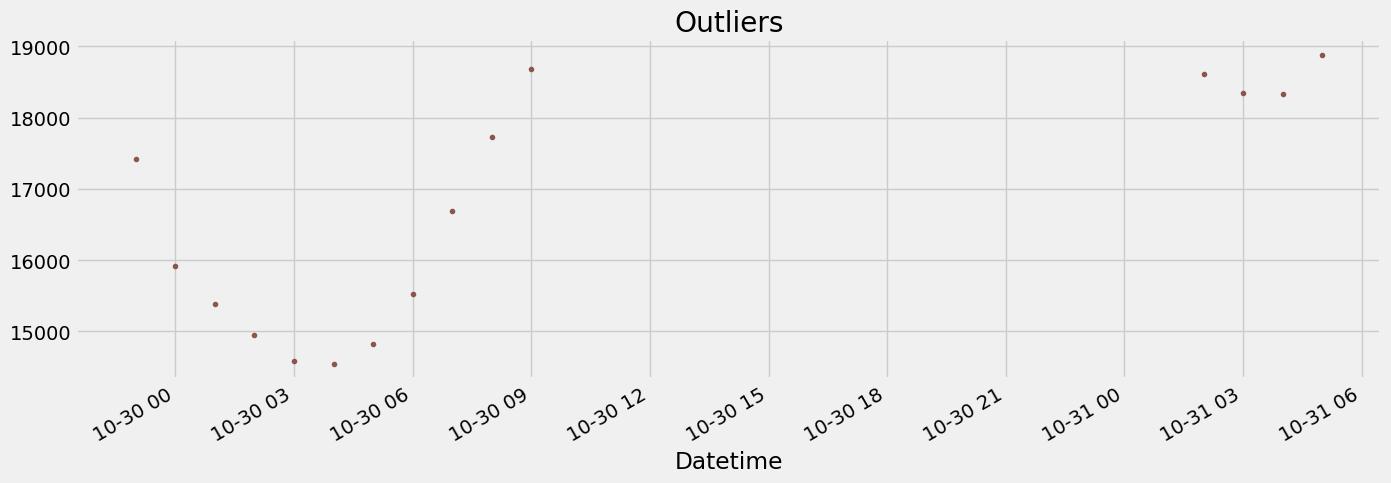

In [ ]:
df.query("PJME_MW < 19_000")["PJME_MW"].plot(
    style=".", figsize=(15, 5), color=color_pal[5], title="Outliers"
)


In [ ]:
df = df.query("PJME_MW > 19_000").copy()


C:\Users\farma\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


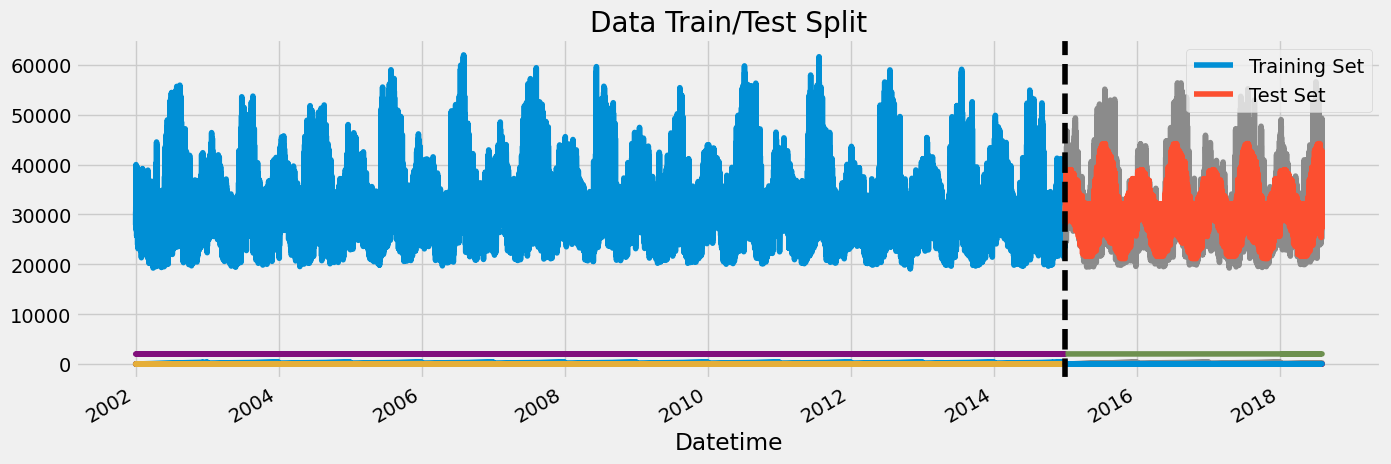

In [19]:
train = df.loc[df.index < "01-01-2015"]
test = df.loc[df.index >= "01-01-2015"]

fig, ax = plt.subplots(figsize=(15, 5))
train.plot(ax=ax, label="Training Set", title="Data Train/Test Split")
test.plot(ax=ax, label="Test Set")
ax.axvline("01-01-2015", color="black", ls="--")
ax.legend(["Training Set", "Test Set"])
plt.show()


1. Time Series Cross Validation

In [20]:
from sklearn.model_selection import TimeSeriesSplit

tss = TimeSeriesSplit(n_splits=5, test_size=24 * 365 * 1, gap=24)
df = df.sort_index()


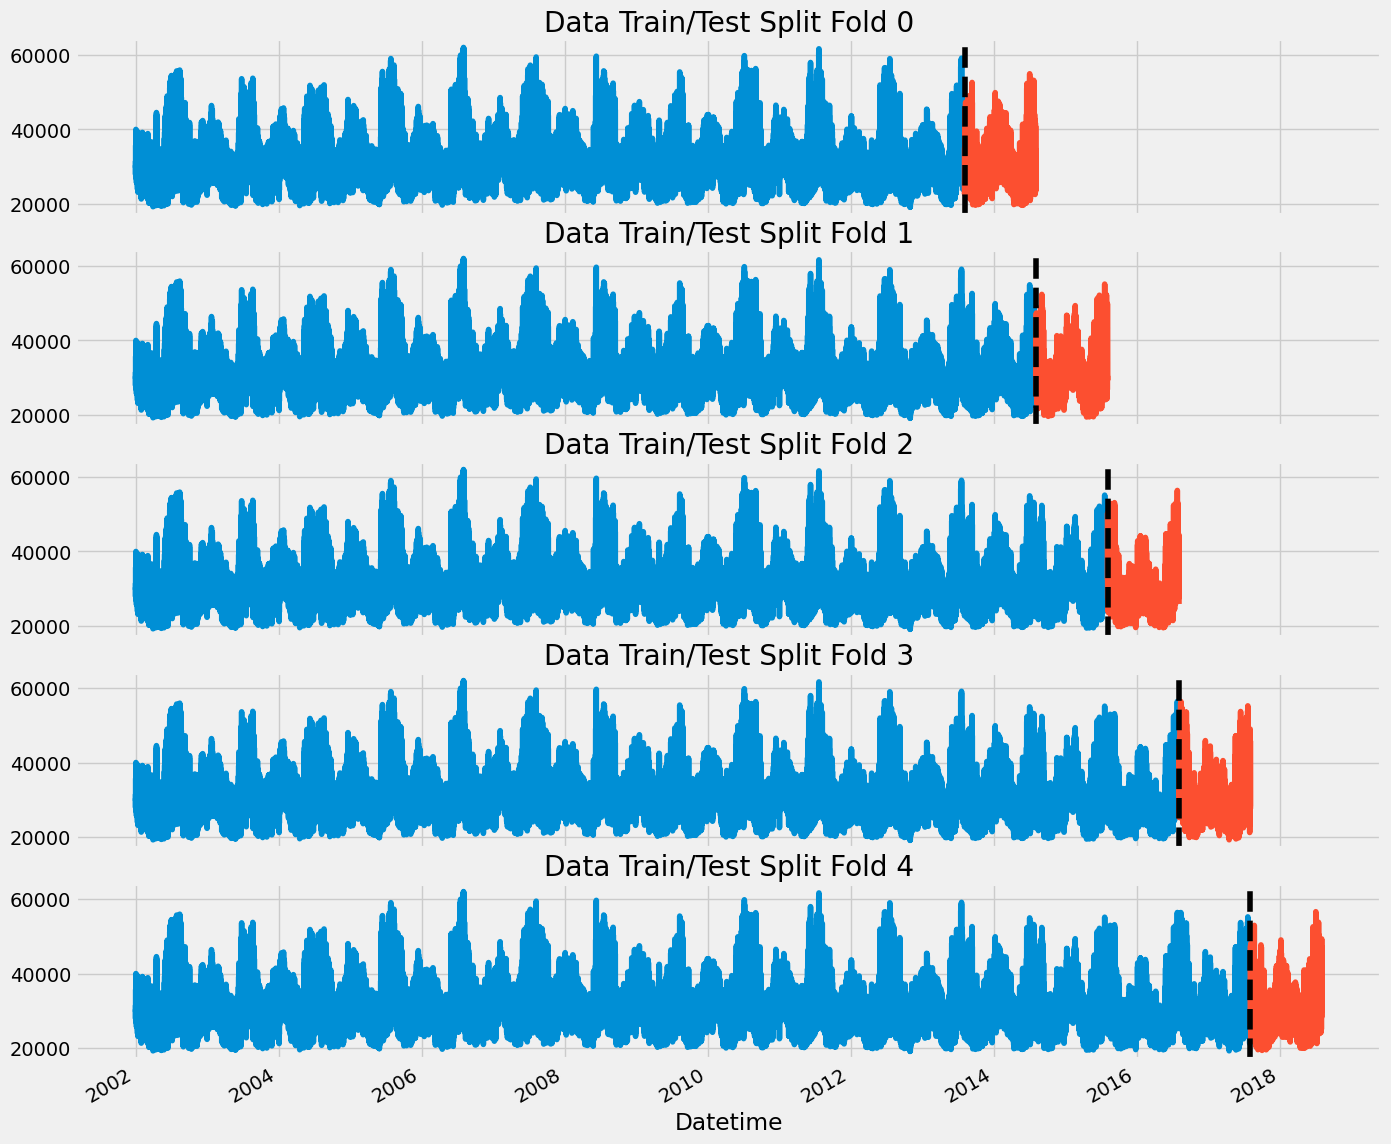

In [21]:
fig, axs = plt.subplots(5, 1, figsize=(15, 15), sharex=True)

fold = 0
for train_idx, val_idx in tss.split(df):
    train = df.iloc[train_idx]
    test = df.iloc[val_idx]
    train["PJME_MW"].plot(
        ax=axs[fold], label="Training Set", title=f"Data Train/Test Split Fold {fold}"
    )
    test["PJME_MW"].plot(ax=axs[fold], label="Test Set")
    axs[fold].axvline(test.index.min(), color="black", ls="--")
    fold += 1
plt.show()


2. Forecasting Horizon Explained¶
The forecast horizon is the length of time into the future for which forecasts are to be prepared. These generally vary from short-term forecasting horizons (less than three months) to long-term horizons (more than two years).

In [22]:
def create_features(df):
    """
    Create time series features based on time series index.
    """
    df = df.copy()
    df["hour"] = df.index.hour
    df["dayofweek"] = df.index.dayofweek
    df["quarter"] = df.index.quarter
    df["month"] = df.index.month
    df["year"] = df.index.year
    df["dayofyear"] = df.index.dayofyear
    df["dayofmonth"] = df.index.day
    df["weekofyear"] = df.index.isocalendar().week
    return df

df = create_features(df)


3. Lag Features¶
What was the target (x) days in the past.

In [ ]:
def add_lags(df):
    target_map = df["PJME_MW"].to_dict()
    df["lag1"] = (df.index - pd.Timedelta("364 days")).map(target_map)
    df["lag2"] = (df.index - pd.Timedelta("728 days")).map(target_map)
    df["lag3"] = (df.index - pd.Timedelta("1092 days")).map(target_map)
    return df


In [24]:
df = add_lags(df)


Train Using Cross Validation

In [25]:
tss = TimeSeriesSplit(n_splits=5, test_size=24 * 365 * 1, gap=24)
df = df.sort_index()


fold = 0
preds = []
scores = []
for train_idx, val_idx in tss.split(df):
    train = df.iloc[train_idx]
    test = df.iloc[val_idx]
    train = create_features(train)
    test = create_features(test)

    FEATURES = [
        "dayofyear",
        "hour",
        "dayofweek",
        "quarter",
        "month",
        "year",
        "lag1",
        "lag2",
        "lag3",
    ]
    TARGET = "PJME_MW"

    X_train = train[FEATURES]
    y_train = train[TARGET]



    X_test = test[FEATURES]
    y_test = test[TARGET]

    reg = xgb.XGBRegressor(base_score=0.5, booster='gbtree',    
                           n_estimators=1000,
                           early_stopping_rounds=50,
                           objective='reg:linear',
                           max_depth=3,
                           learning_rate=0.01)
    reg.fit(X_train, y_train,
            eval_set=[(X_train, y_train), (X_test, y_test)],
            verbose=100)
    y_pred = reg.predict(X_test)
    preds.append(y_pred)
    score = np.sqrt(mean_squared_error(y_test, y_pred))
    scores.append(score)


[0]	validation_0-rmse:32732.29937	validation_1-rmse:31956.12398


C:\Users\farma\AppData\Roaming\Python\Python313\site-packages\xgboost\callback.py:385: UserWarning: [19:00:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\objective\regression_obj.cu:275: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()


[100]	validation_0-rmse:12532.60481	validation_1-rmse:11904.19206
[200]	validation_0-rmse:5746.56735	validation_1-rmse:5359.33544
[300]	validation_0-rmse:3873.12153	validation_1-rmse:3895.64065
[400]	validation_0-rmse:3435.06026	validation_1-rmse:3758.86770
[445]	validation_0-rmse:3365.71022	validation_1-rmse:3764.58924
[0]	validation_0-rmse:32671.76877	validation_1-rmse:32142.13659


C:\Users\farma\AppData\Roaming\Python\Python313\site-packages\xgboost\callback.py:385: UserWarning: [19:00:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\objective\regression_obj.cu:275: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()


[100]	validation_0-rmse:12513.37971	validation_1-rmse:12226.15790
[200]	validation_0-rmse:5754.10264	validation_1-rmse:5660.11921
[300]	validation_0-rmse:3902.17760	validation_1-rmse:3936.47355
[400]	validation_0-rmse:3476.14554	validation_1-rmse:3600.98094
[500]	validation_0-rmse:3356.85845	validation_1-rmse:3527.94073
[600]	validation_0-rmse:3300.52500	validation_1-rmse:3490.45331
[700]	validation_0-rmse:3260.83084	validation_1-rmse:3464.48035
[800]	validation_0-rmse:3223.64823	validation_1-rmse:3443.09857
[900]	validation_0-rmse:3196.85351	validation_1-rmse:3433.34339
[999]	validation_0-rmse:3170.26883	validation_1-rmse:3425.38035
[0]	validation_0-rmse:32630.97820	validation_1-rmse:31069.98423


C:\Users\farma\AppData\Roaming\Python\Python313\site-packages\xgboost\callback.py:385: UserWarning: [19:00:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\objective\regression_obj.cu:275: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()


[100]	validation_0-rmse:12498.63547	validation_1-rmse:11134.00268
[200]	validation_0-rmse:5750.24800	validation_1-rmse:4810.83822
[300]	validation_0-rmse:3914.28351	validation_1-rmse:3546.64150
[400]	validation_0-rmse:3493.43953	validation_1-rmse:3493.40962
[404]	validation_0-rmse:3485.93097	validation_1-rmse:3496.97424
[0]	validation_0-rmse:32528.19057	validation_1-rmse:31474.52153


C:\Users\farma\AppData\Roaming\Python\Python313\site-packages\xgboost\callback.py:385: UserWarning: [19:00:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\objective\regression_obj.cu:275: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()


[100]	validation_0-rmse:12462.40847	validation_1-rmse:12017.01817
[200]	validation_0-rmse:5737.46341	validation_1-rmse:5794.55682
[300]	validation_0-rmse:3915.22047	validation_1-rmse:4382.44899
[400]	validation_0-rmse:3497.21301	validation_1-rmse:4164.88487
[500]	validation_0-rmse:3383.10835	validation_1-rmse:4108.85149
[546]	validation_0-rmse:3353.01885	validation_1-rmse:4106.42909
[0]	validation_0-rmse:32461.76390	validation_1-rmse:31462.57470


C:\Users\farma\AppData\Roaming\Python\Python313\site-packages\xgboost\callback.py:385: UserWarning: [19:00:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\objective\regression_obj.cu:275: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()


[100]	validation_0-rmse:12445.89672	validation_1-rmse:11956.88934
[200]	validation_0-rmse:5752.45741	validation_1-rmse:5608.82298
[300]	validation_0-rmse:3952.24581	validation_1-rmse:4149.28430
[400]	validation_0-rmse:3543.06584	validation_1-rmse:3998.71502
[434]	validation_0-rmse:3491.96329	validation_1-rmse:4001.94699


In [26]:
print(f"Score across folds {np.mean(scores):0.4f}")
print(f"Fold scores:{scores}")


Score across folds 3750.8044
Fold scores:[np.float64(3757.142817751673), np.float64(3424.6575646000174), np.float64(3472.7759551312315), np.float64(4106.1170867691735), np.float64(3993.328609230631)]


4. Predicting the Future
Retraining on all data
To Predict the future we need an emtpy dataframe for future date ranges.
Run those dates through our feature creation code + lag creation

In [27]:
# Retrain on all data
df = create_features(df)

FEATURES = ['dayofyear', 'hour', 'dayofweek', 'quarter', 'month', 'year',
            'lag1','lag2','lag3']
TARGET = 'PJME_MW'

X_all = df[FEATURES]
y_all = df[TARGET]


reg = xgb.XGBRegressor(
    base_score=0.5,
    booster="gbtree",
    n_estimators=500,
    objective="reg:linear",
    max_depth=3,
    learning_rate=0.01,
)
reg.fit(X_all, y_all, eval_set=[(X_all, y_all)], verbose=100)


[0]	validation_0-rmse:32403.50192


C:\Users\farma\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:200: UserWarning: [19:01:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\objective\regression_obj.cu:275: reg:linear is now deprecated in favor of reg:squarederror.
  bst.update(dtrain, iteration=i, fobj=obj)


[100]	validation_0-rmse:12426.86818
[200]	validation_0-rmse:5752.94377
[300]	validation_0-rmse:3972.59557
[400]	validation_0-rmse:3572.98094
[499]	validation_0-rmse:3458.56556


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:linear'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",0.5
,booster,'gbtree'
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import loa

In [ ]:
df.index.max()


Timestamp('2018-08-03 00:00:00')

In [29]:
# Create future dataframe
future = pd.date_range("2018-08-03", "2019-08-01", freq="1h")
future_df = pd.DataFrame(index=future)
future_df["isFuture"] = True
df["isFuture"] = False
df_and_future = pd.concat([df, future_df])
df_and_future = create_features(df_and_future)
df_and_future = add_lags(df_and_future)


In [ ]:
future_w_features = df_and_future.query("isFuture").copy()


In [ ]:
future_w_features["pred"] = reg.predict(future_w_features[FEATURES])


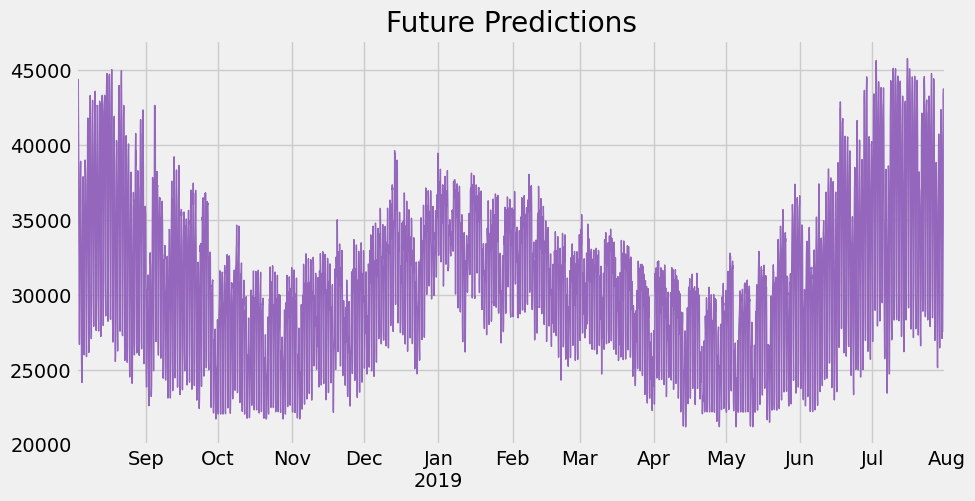

In [32]:
future_w_features["pred"].plot(
    figsize=(10, 5), color=color_pal[4], ms=1, lw=1, title="Future Predictions"
)
plt.show()


Bonus: Saving Model For later

In [ ]:
# Save model
reg.save_model("model.json")


<Axes: title={'center': 'Future Predictions'}>

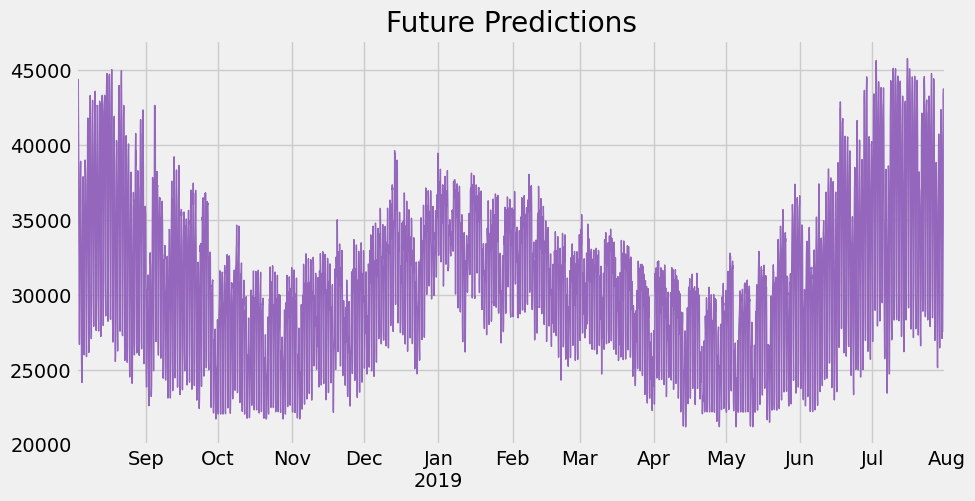

In [ ]:
reg_new = xgb.XGBRegressor()
reg_new.load_model("model.json")
future_w_features["pred"] = reg_new.predict(future_w_features[FEATURES])
future_w_features["pred"].plot(
    figsize=(10, 5), color=color_pal[4], ms=1, lw=1, title="Future Predictions"
)
